### ⚠️ Patched for Local Execution
This notebook was originally designed for Google Colab. It has been automatically patched:
- Google Colab-specific imports and `drive.mount()` calls have been commented out
- Colab file paths (`/content/drive/...`) have been replaced with relative paths (`./`)
- `!pip install` commands have been commented out (install packages in your venv instead)

**To run locally:** activate your Python virtual environment first, then run this notebook in VS Code or Jupyter.

In [1]:
# [PATCHED] from google.colab import drive
# [PATCHED] drive.mount('./')

In [2]:
import random
import numpy as np
import tensorflow as tf
seed_value = 42
np.random.seed(seed_value)
tf.random.set_seed(seed_value)
random.seed(seed_value)

I0000 00:00:1787292777.650533   21067 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
import keras
from keras.applications.xception import preprocess_input

target_size = (224, 224)

# 1. Load training dataset (Note: leading space in path removed)
train_ds = keras.utils.image_dataset_from_directory(
    './/images/train',
    image_size=target_size,
    batch_size=12,
    shuffle=False,
    label_mode='categorical'
)

# 2. Load validation dataset
validation_ds = keras.utils.image_dataset_from_directory(
    './images/val',
    image_size=target_size,
    batch_size=4,
    shuffle=False,
    label_mode='categorical'
)

# 3. Apply Xception preprocess_input mapping
train_generator = train_ds.map(lambda x, y: (preprocess_input(x), y))
validation_generator = validation_ds.map(lambda x, y: (preprocess_input(x), y))

Found 72 files belonging to 2 classes.
Found 20 files belonging to 2 classes.


In [5]:
from keras.applications import Xception
resnet_weights_path = './models/xception_weights_tf_dim_ordering_tf_kernels_notop.h5'
base_model=Xception(include_top=False, pooling='avg', weights=resnet_weights_path)


In [6]:
base_model.summary()

Model: "xception"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, None,      │        864 │ input_layer[0][0] │
│ (Conv2D)            │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, None,      │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, None,      │          0 │ block1_conv1_bn[… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, None,      │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, None,      │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, None,      │          0 │ block1_conv2_bn[… │
│ (Activation)        │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, None,      │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, None,      │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, None,      │          0 │ block2_sepconv1_… │
│ (Activation)        │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, None,      │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, None,      │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │      8,192 │ block1_conv2_act… │
│                     │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, None,      │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, None,      │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ None, 128)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, None,      │          0 │ block2_pool[0][0… │
│                     │ None, 128)        │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, None,      │          0 │ add[0][0]       

 Total params: 20,861,480 (79.58 MB)

 Trainable params: 20,806,952 (79.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [7]:
len(base_model.layers)

133

In [8]:
base_model.trainable=False

In [9]:
from keras import Sequential
from keras.layers import Dense
model = Sequential()
model.add(base_model)
model.add(Dense(2, activation='softmax'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,865,578 (79.60 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [10]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [11]:
epochs=20
history = model.fit(
    x=train_generator,
    steps_per_epoch=len(train_generator),
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=len(validation_generator)
)

Epoch 1/20


/home/aziz1/miniconda3/envs/tf_gpu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
E0000 00:00:1787292891.685551   21373 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1787292894.073116   21373 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1787292894.339972   21373 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1787292897.478228   21373 cuda_timer.cc:

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.3889 - loss: 1.0022

E0000 00:00:1787292901.697386   21376 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1787292903.864959   21376 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1787292904.362977   21376 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1787292905.329272   21376 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


6/6 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 0.3889 - loss: 1.0022 - val_accuracy: 0.5000 - val_loss: 0.7742
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5417 - loss: 0.6887 - val_accuracy: 0.6500 - val_loss: 0.6166
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9306 - loss: 0.5294 - val_accuracy: 0.9500 - val_loss: 0.5145
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9722 - loss: 0.4509 - val_accuracy: 0.9000 - val_loss: 0.4488
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9444 - loss: 0.3999 - val_accuracy: 0.9500 - val_loss: 0.3924
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9583 - loss: 0.3501 - val_accuracy: 1.0000 - val_loss: 0.3406
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9583 - loss: 0.3026 - val_accuracy: 1.0000 - val_loss: 0.2969
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9861 - loss: 0.2626 - val_accuracy: 1.0000 - val_loss: 0.2623
Epoch 9/20
6

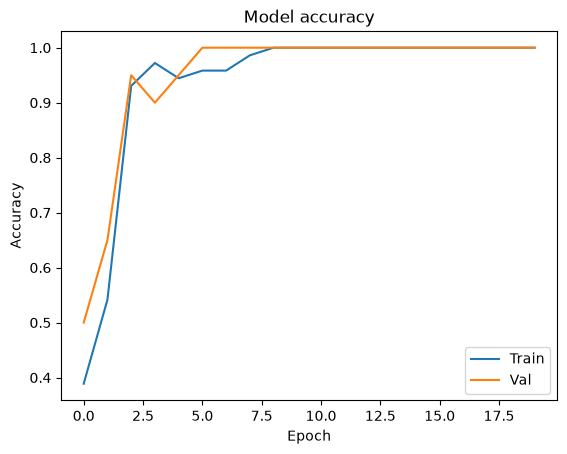

In [12]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='lower right')
plt.show()

In [14]:
score = model.evaluate(validation_generator, steps=len(validation_generator))
print('Test accuracy:', round(score[1]*100, 2))

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 1.0000 - loss: 0.1090
Test accuracy: 100.0


In [15]:
y_pred = model.predict(validation_generator, steps=len(validation_generator))
y_pred

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step


array([[0.979416  , 0.02058405],
       [0.95999193, 0.04000806],
       [0.9390071 , 0.06099292],
       [0.9960854 , 0.0039146 ],
       [0.98822415, 0.01177585],
       [0.9981096 , 0.00189042],
       [0.9624257 , 0.03757438],
       [0.99754435, 0.00245565],
       [0.91965294, 0.08034707],
       [0.9939792 , 0.00602079],
       [0.00308733, 0.9969126 ],
       [0.00439009, 0.9956099 ],
       [0.00618854, 0.9938115 ],
       [0.01160389, 0.98839617],
       [0.01968991, 0.98031014],
       [0.00616255, 0.9938374 ],
       [0.01931863, 0.98068136],
       [0.00707709, 0.9929229 ],
       [0.00149713, 0.99850285],
       [0.00254872, 0.99745125]], dtype=float32)

In [16]:
y_pred = np.argmax(y_pred, axis=1)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [18]:
import keras

# 1. Load raw dataset
val_ds_raw = keras.utils.image_dataset_from_directory(
    './images/val',
    image_size=(224, 224),
    batch_size=4,
    shuffle=False,
    label_mode='categorical'
)

# 2. Get class names list
class_names = val_ds_raw.class_names  # e.g., ['rural', 'urban']

# 3. Recreate class_indices dictionary if needed
class_indices = {name: index for index, name in enumerate(class_names)}
print("Class Indices:", class_indices)

Found 20 files belonging to 2 classes.


Class Indices: {'rural': 0, 'urban': 1}


In [20]:
class_labels = val_ds_raw.class_names
print(class_labels)

['rural', 'urban']


In [22]:
import numpy as np

# 1. Extract ground truth labels from all batches in the dataset
y_true_one_hot = np.concatenate([y.numpy() for _, y in validation_generator], axis=0)

# 2. Convert one-hot vectors to integer class indices
y_true = np.argmax(y_true_one_hot, axis=1)

print(y_true)

[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1]


In [23]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
cm

array([[10,  0],
       [ 0, 10]])

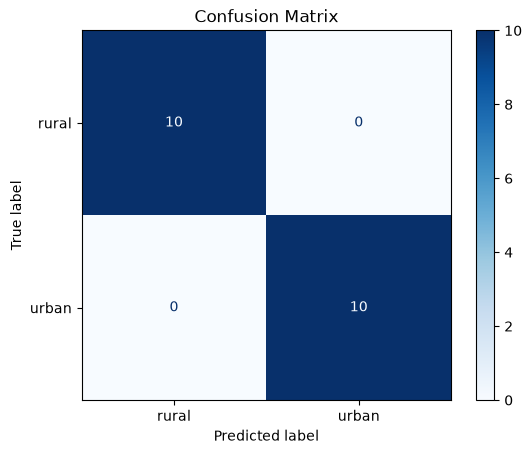

In [24]:
from sklearn.metrics import  ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Confusion Matrix')
plt.show()

In [26]:
model.save("./models/class_urban_rural_model.keras")

In [28]:
from keras.models import load_model
loaded_model = load_model("./models/class_urban_rural_model.keras")

In [29]:
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         4,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,873,776 (79.63 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

 Optimizer params: 8,198 (32.03 KB)

In [31]:
from keras.preprocessing import image
from keras.applications.xception import preprocess_input

img_path = './images/val/rural/rural10.jpeg'
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_arr_proc = preprocess_input(img_array)


In [32]:
prediction = loaded_model.predict(img_arr_proc)
prediction

E0000 00:00:1787293109.685104   21373 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1787293111.313631   21373 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1787293111.894617   21373 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1787293112.816405   21373 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


array([[0.98463804, 0.01536201]], dtype=float32)

In [33]:
class_index = np.argmax(prediction, axis=1)
class_index

array([0])

In [34]:
class_labels = ['rural', 'urban']
predicted_class_label = class_labels[class_index[0]]
predicted_class_label

'rural'

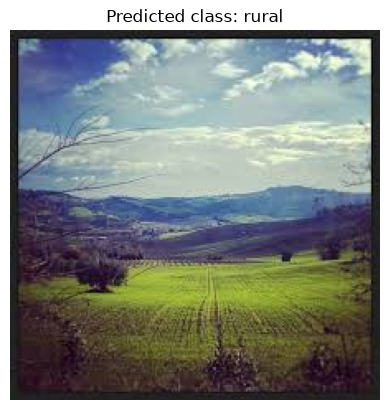

In [35]:
plt.imshow(img)
plt.title(f'Predicted class: {predicted_class_label}')
plt.axis('off')
plt.show()

In [36]:
def load_and_preprocess_image(image_path):
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_arr_proc = preprocess_input(img_array)
    return img, img_arr_proc

Some Urban Images: 


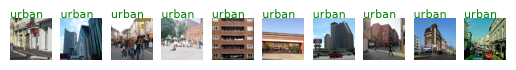

In [37]:
import os
class_labels = ['rural', 'urban']

folder_path_urban = "./images/val/urban"

jpeg_files_urban = [f for f in os.listdir(folder_path_urban) if f.endswith(".jpeg") or f.endswith(".jpg")]

num_photos_to_display = 10
true_class="urban"
print("Some Urban Images: ")
for i, jpeg_file in enumerate(jpeg_files_urban[:num_photos_to_display]):
    img_path = os.path.join(folder_path_urban, jpeg_file)
    img, img_array = load_and_preprocess_image(img_path)
    prediction = loaded_model.predict(img_array ,verbose=0)
    class_index = np.argmax(prediction, axis=1)
    predicted_class = class_labels[class_index[0]]
    text_color = 'green' if true_class == predicted_class else 'red'
    plt.subplot(1, num_photos_to_display, i + 1)
    plt.imshow(img)
    plt.text(0, 0, f'{predicted_class}', fontsize=8, color=text_color)
    plt.axis("off")

plt.show()


Some Rural Images: 


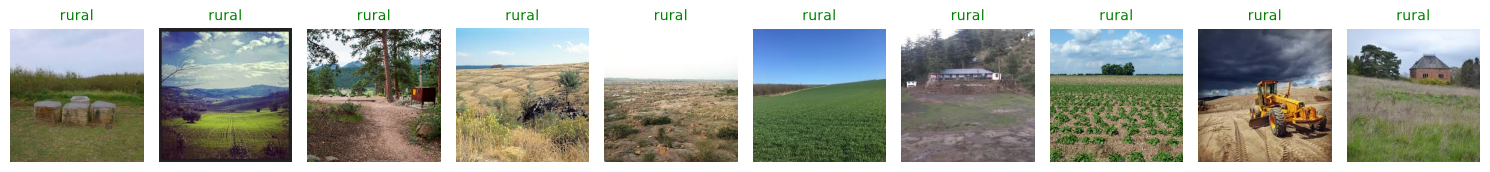

In [39]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 1. Use os.path.join or forward slashes for Linux compatibility
folder_path_rural = os.path.join("images", "val", "rural")

jpeg_files_rural = [
    f for f in os.listdir(folder_path_rural) 
    if f.lower().endswith((".jpeg", ".jpg"))
]

num_photos_to_display = 10
true_class = "rural"
print("Some Rural Images: ")

plt.figure(figsize=(15, 3))

for i, jpeg_file in enumerate(jpeg_files_rural[:num_photos_to_display]):
    img_path = os.path.join(folder_path_rural, jpeg_file)
    img, img_array = load_and_preprocess_image(img_path)
    
    prediction = loaded_model.predict(img_array, verbose=0)
    class_index = np.argmax(prediction, axis=1)
    predicted_class = class_labels[class_index[0]]
    
    text_color = 'green' if true_class == predicted_class else 'red'
    
    plt.subplot(1, num_photos_to_display, i + 1)
    plt.imshow(img)
    plt.title(f'{predicted_class}', fontsize=10, color=text_color)  # Replaced text() with title() for clean alignment
    plt.axis("off")

plt.tight_layout()
plt.show()